# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eminamandzukic/FlyRank_starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The main focus of this project is to answer the following question:

 **Can historical search-performance signals be used to identify content that is more likely to experience a meaningful decline in the following month?**

The goal is to use this prediction to decide which already-visible content should be reviewed first for possible refresh, protection, or monitoring. The model is used as a decision-support tool to help prioritise human review and it is not meant to automatically change content or explain why Google rankings change.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This project utilizes the FlyRank internship warehouse (build  `v20260703 `), primarily relying on the  `fact_content_daily_performance ` table, which contains daily search-performance metrics for pseudonymized clients and content items. The dataset comprises approximately 78.8 million daily performance records spanning late January 2025 through June 2026. Additionally, the  `dim_clients ` table is used to verify historical data availability across clients.

The model utilizes search signals from a given month to predict whether a content item will experience a meaningful performance decline in the subsequent month. Training is conducted on historical monthly pairs from February 2025 onward, while the period from April 2026 to May 2026 serves as the primary validation set.

To ensure data quality, the dataset is filtered to include only content items with at least 200 impressions during the feature month. Clients lacking a full month of historical search data are excluded from the analysis. GA4-based features are intentionally omitted from the final model due to partial data availability across the warehouse, preventing missing values from being erroneously interpreted as zero engagement.

Finally, client and content identifiers are strictly used for grouping and joining operations rather than as predictive features, ensuring that no client names, URLs, or private query details are incorporated into the model.

In [17]:
import getpass
import duckdb
from huggingface_hub import hf_hub_download

HF_TOKEN = getpass.getpass(
    "Hugging Face READ token: "
).strip()

con = duckdb.connect()

march_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=HF_TOKEN
)

april_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-04/data_0.parquet",
    token=HF_TOKEN
)

window_check = con.sql(f"""
    SELECT
        'March 2026' AS month,
        COUNT(*) AS rows,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM read_parquet('{march_path}')

    UNION ALL

    SELECT
        'April 2026' AS month,
        COUNT(*) AS rows,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM read_parquet('{april_path}')
""").df()

window_check

,month,rows,min_date,max_date
0,March 2026,9841378,2026-03-01,2026-03-31
1,April 2026,10424730,2026-04-01,2026-04-30


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The objective is framed as a combined binary classification and ranking task. For each content item, the model leverages search-performance signals aggregated over a single feature month to estimate the risk of a meaningful performance decline in the subsequent month.

The target variable, `is_declining`, is defined as a binary indicator denoting whether the average daily impressions in the outcome month drop below 80% of the average daily impressions recorded during the feature month.

The final feature set consists of four key search metrics:
- Monthly impressions
- Monthly clicks
- Average search position
- Click-through rate (CTR)


A rule-based heuristic serves as the primary baseline for evaluation. This baseline filters for content items with at least 200 impressions and an average search position exceeding 10, subsequently ranking qualifying pages in descending order of impression volume.

Two supervised machine learning models are evaluated against this baseline: Logistic Regression and Random Forest. Logistic Regression provides a simple, highly interpretable benchmark, whereas Random Forest is incorporated to evaluate whether capturing nonlinear feature interactions improves overall predictive performance.

Validation is structured using a time-aware splitting strategy. Models are trained on historical monthly pairs prior to the validation horizon, while the transition from April 2026 to May 2026 is held out as the primary validation set. Although a random split was conducted strictly as an audit baseline, time-aware validation is prioritized to prevent temporal data leakage and realistic performance overestimation.

Finally, a data leakage audit was performed to confirm that client and content identifiers, target-derived variables, and future outcome metrics are strictly excluded from the training feature set.

In [18]:
import pandas as pd

feature_cols = [
    "impressions_feature",
    "clicks_feature",
    "avg_position_feature",
    "ctr_feature",
]

methodology_summary = pd.DataFrame({
    "Setting": [
        "Decline threshold",
        "Minimum impressions",
        "Baseline position cutoff",
        "Training period",
        "Validation period",
        "Models",
    ],
    "Value": [
        "Outcome daily avg. < 80% of feature month",
        "200",
        "Average position > 10",
        "Feb 2025 - Apr 2026",
        "Apr 2026 - May 2026",
        "Logistic Regression, Random Forest",
    ],
})

methodology_summary

forbidden_features = {
    "client_hash_id",
    "content_hash_id",
    "impressions_outcome",
    "avg_daily_impressions_outcome",
    "outcome_month",
}

assert not set(feature_cols).intersection(forbidden_features)

methodology_summary

,Setting,Value
0,Decline threshold,Outcome daily avg. < 80% of feature month
1,Minimum impressions,200
2,Baseline position cutoff,Average position > 10
3,Training period,Feb 2025 - Apr 2026
4,Validation period,Apr 2026 - May 2026
5,Models,"Logistic Regression, Random Forest"


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The three approaches were evaluated on the same time-aware validation split spanning April 2026 to May 2026, during which the decline base rate stood at 57.6%.

Logistic Regression achieved the highest overall ROC-AUC at 0.588, outperforming both the rule-based baseline (0.554) and Random Forest (0.539). Nevertheless, because the primary objective of the system is to prioritize a limited subset of content items for human review, top-heavy ranking metrics such as Precision at K (Precision@K) carry greater operational significance.

When evaluating the highest-priority segments of the review queue, the simple rule-based heuristic outperformed both learned models. Specifically, the baseline achieved a Precision@20 of 0.60, Precision@50 of 0.66, and Precision@100 of 0.70. In comparison, Logistic Regression achieved 0.55, 0.54, and 0.55 across the respective thresholds, while Random Forest achieved 0.40, 0.52, and 0.55.

These findings indicate that historical search signals contain some predictive signal, but the learned models do not provide a clear improvement over the straightforward rule-based approach for the actionable ranking task. Consequently, the rule-based baseline remains the stronger option for prioritizing content items for human review under the current validation setting.

In [19]:
results = pd.DataFrame({
    "Method": [
        "Week-4 baseline",
        "Logistic Regression",
        "Random Forest",
    ],
    "ROC-AUC": [
        0.554,
        0.588,
        0.539,
    ],
    "Precision@20": [
        0.60,
        0.55,
        0.40,
    ],
    "Precision@50": [
        0.66,
        0.54,
        0.52,
    ],
    "Precision@100": [
        0.70,
        0.55,
        0.55,
    ],
    "Precision@500": [
        0.666,
        0.504,
        0.584,
    ],
})

validation_base_rate = 0.576

print("Validation base rate:", validation_base_rate)
results

Validation base rate: 0.576


,Method,ROC-AUC,Precision@20,Precision@50,Precision@100,Precision@500
0,Week-4 baseline,0.554,0.60,0.66,0.70,0.666
1,Logistic Regression,0.588,0.55,0.54,0.55,0.504
2,Random Forest,0.539,0.40,0.52,0.55,0.584


## 5. Limitations

*What this work cannot claim.*

Several limitations should be taken into consideration when interpreting the findings of this study.

First, the target variable `is_declining` serves as a proxy for review priority. A drop in average daily impressions does not inherently indicate that a page requires a content refresh, nor does it capture the underlying causes driving the performance decline.

Second, the feature set is intentionally restricted to four historical search-performance signals. Other factors-such as content quality, topical shifts, seasonal trends, competitor activity, and previous content updates-are not represented in the model but may also contribute to future performance fluctuations.

Furthermore, the primary evaluation relies on a single held-out temporal transition from April 2026 to May 2026. Generalizability across other periods remains unverified, particularly given that observed decline rates fluctuate over time.

The monthly modeling pipeline uses an inner join between the feature and outcome periods. For the primary April 2026 - May 2026 validation period, a direct check showed that all 362,172 content items observed in April were also present in May, meaning no content items were excluded because of this join during the main evaluation period.

Finally, the analysis is fundamentally observational. The results establish predictive associations rather than causal relationships; therefore, they do not prove that any specific search metric causes future decline, nor that refreshing a high-priority page will improve its future performance. The system should therefore be interpreted as a decision-support tool for prioritizing human review workflows.

In [20]:
may_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-05/data_0.parquet",
    token=HF_TOKEN
)

join_check = con.sql(f"""
    WITH april AS (
        SELECT DISTINCT client_hash_id, content_hash_id
        FROM read_parquet('{april_path}')
    ),
    may AS (
        SELECT DISTINCT client_hash_id, content_hash_id
        FROM read_parquet('{may_path}')
    )

    SELECT
        COUNT(*) AS april_items,
        COUNT(*) FILTER (
            WHERE m.content_hash_id IS NOT NULL
        ) AS present_in_both,
        COUNT(*) FILTER (
            WHERE m.content_hash_id IS NULL
        ) AS absent_from_may
    FROM april a
    LEFT JOIN may m
        ON a.client_hash_id = m.client_hash_id
       AND a.content_hash_id = m.content_hash_id
""").df()

join_check

,april_items,present_in_both,absent_from_may
0,362172,362172,0


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the experimental findings, the primary recommendation is to retain the transparent rule-based heuristic as the core ranking mechanism for human review workflows.

Content items are designated for `review_for_refresh` when they maintain meaningful search visibility but exhibit an average search position worse than 10. Within this subset, pages are ranked in descending order of impression volume to ensure that high-visibility opportunities receive priority review.

Conversely, content items already ranking within the top 10 positions are categorized under `protect_and_monitor`. These pages reflect strong search positioning and do not meet the criteria for the primary review rule.

Although the decline probabilities generated by the learned models may be retained as secondary exploratory signals, they should not dictate the final review queue ordering, as they failed to outperform the baseline at the top of the validation queue.

Finally, all outputs require human review before any intervention occurs. The ranked queue should serve strictly as a decision-support tool to guide editorial attention rather than driving automated actions such as content rewriting, publishing, deletion, or modification.

In [21]:
recommendation_summary = pd.DataFrame({
    "Action": [
        "review_for_refresh",
        "protect_and_monitor",
    ],
    "Rule": [
        "Average position > 10",
        "Average position <= 10",
    ],
    "Reason code": [
        "visible_but_not_top10",
        "strong_current_position",
    ],
    "Human decision": [
    "Review for possible refresh",
    "Protect and monitor",
],
})

recommendation_summary

,Action,Rule,Reason code,Human decision
0,review_for_refresh,Average position > 10,visible_but_not_top10,Review for possible refresh
1,protect_and_monitor,Average position <= 10,strong_current_position,Protect and monitor


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The main paper figure compares Precision@K across the rule-based baseline, Logistic Regression, and Random Forest on the same time-aware validation split. This directly shows how each method performs at the highest-priority parts of the review queue.

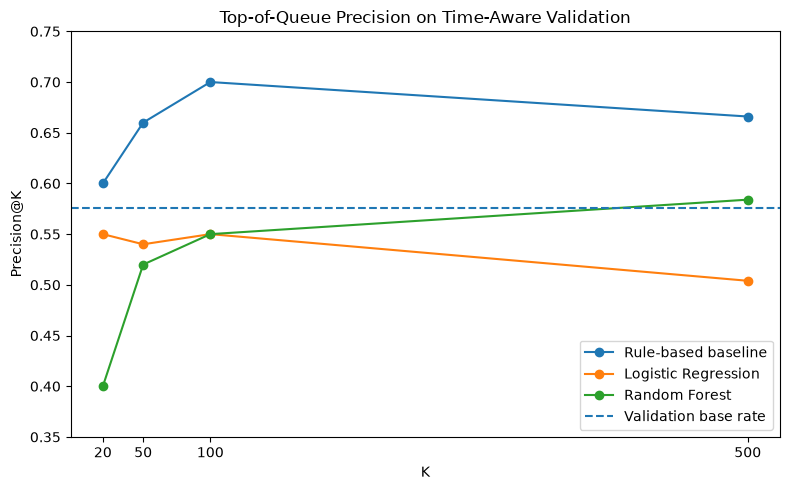

Saved: ../figures/precision_at_k_comparison.png


In [22]:
from pathlib import Path
import matplotlib.pyplot as plt

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

k_values = [20, 50, 100, 500]

baseline_precision = [0.60, 0.66, 0.70, 0.666]
logistic_precision = [0.55, 0.54, 0.55, 0.504]
rf_precision = [0.40, 0.52, 0.55, 0.584]

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    baseline_precision,
    marker="o",
    label="Rule-based baseline",
)

plt.plot(
    k_values,
    logistic_precision,
    marker="o",
    label="Logistic Regression",
)

plt.plot(
    k_values,
    rf_precision,
    marker="o",
    label="Random Forest",
)

plt.axhline(
    validation_base_rate,
    linestyle="--",
    label="Validation base rate",
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Top-of-Queue Precision on Time-Aware Validation")
plt.xticks(k_values)
plt.ylim(0.35, 0.75)
plt.legend()
plt.tight_layout()

figure_path = figures_dir / "precision_at_k_comparison.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

**Takeaway**: The rule-based baseline achieves the strongest Precision@K across the highest-priority portions of the review queue, while both learned models perform below the validation base rate at most evaluated cutoffs.

The second artifact summarizes the validation performance of all three approaches on the same time-aware split.

In [23]:
paper_results_table = results.copy()

paper_results_table["ROC-AUC"] = paper_results_table["ROC-AUC"].round(3)
paper_results_table["Precision@20"] = paper_results_table["Precision@20"].round(3)
paper_results_table["Precision@50"] = paper_results_table["Precision@50"].round(3)
paper_results_table["Precision@100"] = paper_results_table["Precision@100"].round(3)
paper_results_table["Precision@500"] = paper_results_table["Precision@500"].round(3)

paper_results_table

,Method,ROC-AUC,Precision@20,Precision@50,Precision@100,Precision@500
0,Week-4 baseline,0.554,0.60,0.66,0.70,0.666
1,Logistic Regression,0.588,0.55,0.54,0.55,0.504
2,Random Forest,0.539,0.40,0.52,0.55,0.584


## 8. 5-Minute Demo Outline

1. **Problem** - Explain the goal of identifying which visible content items should be reviewed first for possible refresh or monitoring.

2. **Data** - Briefly introduce the FlyRank warehouse and explain that historical monthly search signals are used to predict next-month decline.

3. **Method** - Present the rule-based baseline, Logistic Regression, and Random Forest, together with the time-aware validation design.

4. **Main result** - Show the Precision@K figure and explain that although Logistic Regression achieved the highest ROC-AUC, the simple rule-based baseline performed better at the top of the review queue.

5. **Recommendation** - Conclude that the rule-based baseline should remain the primary ranking mechanism, while model scores can be retained as secondary exploratory signals. All final actions remain subject to human review.

## 9. Social Post Cut

I explored whether historical search-performance signals can help prioritize content that may experience a meaningful decline in the following month.

Using the FlyRank internship warehouse, I compared a transparent rule-based baseline against Logistic Regression and Random Forest under time-aware validation.

The main result was that although Logistic Regression achieved the highest ROC-AUC, the simple baseline performed better at the top of the ranked review queue, reaching a Precision@100 of 0.70 compared with 0.55 for both learned models.

This suggests that for this decision setting, a simpler and more interpretable rule can be more useful than a more complex model when the actual goal is to prioritize a small number of pages for human review.

The full analysis includes the validation design, leakage audit, Precision@K comparison, limitations, and final action playbook.

## 10. Employer-Facing Summary

I built a time-aware content-prioritization pipeline using the FlyRank internship warehouse, working with approximately 78.8 million daily search-performance records and comparing a transparent heuristic against Logistic Regression and Random Forest.

The analysis showed that although Logistic Regression achieved the highest ROC-AUC, the rule-based baseline performed better at the top of the ranked review queue, reaching Precision@100 of 0.70 compared with 0.55 for both learned models.

The final system therefore prioritizes interpretability and operational usefulness, using the baseline as the primary ranking mechanism while keeping all recommendations subject to human review.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
